# Damping Sweep Aggregation (`B=200`)

This notebook aggregates metrics from `results/metrics_*.json` for runs with the same seed and different `ij_damping`.

It plots `ij_damping` vs:
- uniform `all_covered`
- uniform `fraction_covered`
- pointwise `fraction_covered`
- `c_uniform`
- `se_summary.max`
- `boot_weighted_loss_mean` from `bootstrap_compare`

In [30]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path("results")
JSON_GLOB = "metrics_*.json"
TARGET_B_PREFIX = 200

# Optional filters; set to None to disable.
FILTER_SEED = 1
FILTER_B = 200

In [32]:
def _parse_alpha_key(alpha_key: str, fallback=None):
    m = re.match(r"alpha_(.+)", str(alpha_key))
    if not m:
        return fallback
    return float(m.group(1).replace("p", "."))


def _parse_k_key(k_key: str, fallback=None):
    m = re.match(r"k_(\d+)", str(k_key))
    if not m:
        return fallback
    return int(m.group(1))


def _extract_boot_weighted_loss_mean(data: dict):
    bc = data.get("bootstrap_compare", {}) or {}
    methods = bc.get("methods", {}) or {}
    primary = bc.get("primary_method")

    if primary in methods:
        return (((methods.get(primary) or {}).get("loss") or {}).get("boot_weighted_loss_mean"))

    for method_key in ("ij", "exact"):
        if method_key in methods:
            return (((methods.get(method_key) or {}).get("loss") or {}).get("boot_weighted_loss_mean"))

    return np.nan


def collect_uniform_stats(results_dir: Path, json_glob: str = "metrics_*.json") -> pd.DataFrame:
    rows = []
    for path in sorted(results_dir.glob(json_glob)):
        with path.open("r", encoding="utf-8") as f:
            data = json.load(f)

        boot = data.get("bootstrap", {})
        run_seed = data.get("train_cfg_attn", {}).get("seed")
        B = boot.get("B")
        ij_damping = boot.get("ij_damping")
        boot_weighted_loss_mean = _extract_boot_weighted_loss_mean(data)

        coverage = data.get("coverage_by_alpha_k", {})
        for alpha_key, alpha_block in coverage.items():
            for k_key, k_block in alpha_block.items():
                alpha_val = k_block.get("alpha", _parse_alpha_key(alpha_key))
                k_val = k_block.get("k", _parse_k_key(k_key))

                for split in ("train", "test"):
                    by_prefix = (
                        k_block.get(split, {})
                        .get("raw_scores", {})
                        .get("by_prefix", {})
                    )
                    for prefix_key, entry in by_prefix.items():
                        uniform = entry.get("uniform", {})
                        pointwise = entry.get("pointwise", {})
                        b_prefix = entry.get("B_prefix", prefix_key)

                        rows.append(
                            {
                                "file": path.name,
                                "seed": run_seed,
                                "B": B,
                                "ij_damping": ij_damping,
                                "boot_weighted_loss_mean": boot_weighted_loss_mean,
                                "split": split,
                                "alpha": alpha_val,
                                "k": k_val,
                                "B_prefix": b_prefix,
                                "uniform_all_covered": uniform.get("all_covered", entry.get("uniform_all_covered")),
                                "uniform_fraction_covered": uniform.get("fraction_covered", entry.get("uniform_fraction_covered")),
                                "pointwise_fraction_covered": pointwise.get("fraction_covered", entry.get("pointwise_fraction_covered")),
                                "c_uniform": uniform.get("c_uniform"),
                                "se_max": (entry.get("se_summary") or {}).get("max"),
                            }
                        )

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    numeric_cols = [
        "seed", "B", "ij_damping", "boot_weighted_loss_mean", "alpha", "k", "B_prefix",
        "uniform_all_covered", "uniform_fraction_covered", "pointwise_fraction_covered", "c_uniform", "se_max",
    ]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


raw_df = collect_uniform_stats(RESULTS_DIR, JSON_GLOB)
if raw_df.empty:
    raise RuntimeError("No matching metrics JSON files found or parsed.")

df = raw_df.copy()
if FILTER_SEED is not None:
    df = df[df["seed"] == FILTER_SEED]
if FILTER_B is not None:
    df = df[df["B"] == FILTER_B]

b200_df = df[df["B_prefix"] == TARGET_B_PREFIX].copy()
if b200_df.empty:
    raise RuntimeError(f"No rows found for B_prefix={TARGET_B_PREFIX}. Check filters or available files.")

agg = (
    b200_df.groupby(["ij_damping", "split", "alpha", "k"], as_index=False)
    .agg(
        n_rows=("file", "size"),
        n_files=("file", "nunique"),
        uniform_all_covered_mean=("uniform_all_covered", "mean"),
        uniform_fraction_covered_mean=("uniform_fraction_covered", "mean"),
        pointwise_fraction_covered_mean=("pointwise_fraction_covered", "mean"),
        c_uniform_mean=("c_uniform", "mean"),
        se_max_mean=("se_max", "mean"),
        boot_weighted_loss_mean_mean=("boot_weighted_loss_mean", "mean"),
    )
    .sort_values(["split", "alpha", "k", "ij_damping"])
)

print("Parsed rows:", len(raw_df))
print("Rows after filters:", len(df))
print("Rows at B_prefix=200:", len(b200_df))
print("Unique damping values:", sorted(agg["ij_damping"].dropna().unique()))
agg.head(20)

Parsed rows: 1760
Rows after filters: 1760
Rows at B_prefix=200: 176
Unique damping values: [np.float64(0.0001), np.float64(0.0001931), np.float64(0.0003728), np.float64(0.000430833), np.float64(0.000488667), np.float64(0.0005465), np.float64(0.000604333), np.float64(0.000662167), np.float64(0.0007197), np.float64(0.000780818), np.float64(0.000841636), np.float64(0.000902455), np.float64(0.000963273), np.float64(0.00102409), np.float64(0.00108491), np.float64(0.00114573), np.float64(0.00120655), np.float64(0.00126736), np.float64(0.001389), np.float64(0.002683), np.float64(0.005179), np.float64(0.01)]


,ij_damping,split,alpha,k,n_rows,n_files,uniform_all_covered_mean,uniform_fraction_covered_mean,pointwise_fraction_covered_mean,c_uniform_mean,se_max_mean,boot_weighted_loss_mean_mean
0,0.000100,test,0.05,2,1,1,1.0,1.000000,1.000000,5.352855,11.319064,46.544979
8,0.000193,test,0.05,2,1,1,1.0,1.000000,1.000000,5.862746,2.598290,1.361771
16,0.000373,test,0.05,2,1,1,1.0,1.000000,1.000000,5.958570,0.809435,0.085149
24,0.000431,test,0.05,2,1,1,1.0,1.000000,0.999493,5.975809,0.660057,0.055946
32,0.000489,test,0.05,2,1,1,1.0,1.000000,0.998478,5.922882,0.565111,0.041054
40,0.000547,test,0.05,2,1,1,1.0,1.000000,0.992390,5.861982,0.500329,0.032538
48,0.000604,test,0.05,2,1,1,1.0,1.000000,0.983257,5.767777,0.453462,0.027252
56,0.000662,test,0.05,2,1,1,1.0,1.000000,0.970066,5.679076,0.417821,0.023767
64,0.000720,test,0.05,2,1,1,1.0,1.000000,0.959411,5.610639,0.395341,0.021372
72,0.000781,test,0.05,2,1,1,1.0,1.000000,0.945205,5.625079,0.381009,0.019566


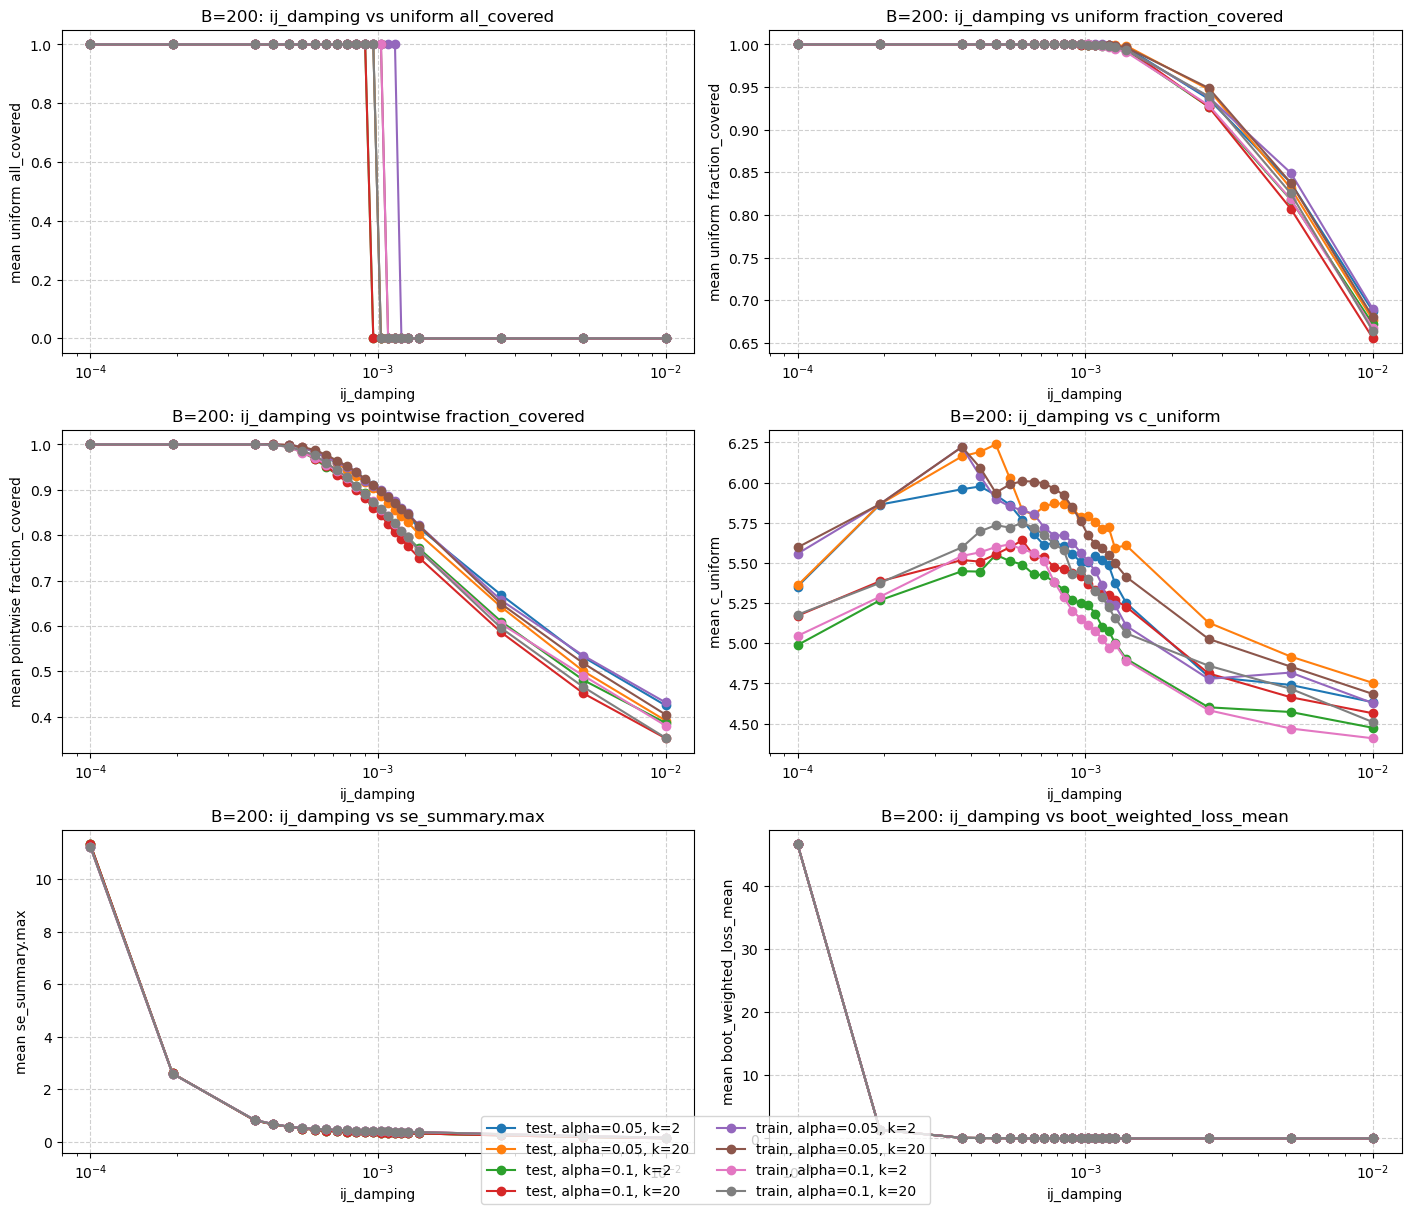

In [33]:
def _plot_metric(ax, metric_col: str, y_label: str, title: str):
    for (split, alpha_val, k_val), g in agg.groupby(["split", "alpha", "k"]):
        gg = g.sort_values("ij_damping")
        label = f"{split}, alpha={alpha_val}, k={int(k_val)}"
        ax.plot(gg["ij_damping"], gg[metric_col], marker="o", label=label)
    ax.set_xscale("log")
    ax.set_xlabel("ij_damping")
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.6)


fig, axes = plt.subplots(3, 1, figsize=(14, 12), constrained_layout=True)

_plot_metric(
    axes[0],
    metric_col="uniform_all_covered_mean",
    y_label="mean uniform all_covered",
    title="B=200: ij_damping vs uniform all_covered",
)
_plot_metric(
    axes[1],
    metric_col="pointwise_fraction_covered_mean",
    y_label="mean pointwise fraction_covered",
    title="B=200: ij_damping vs pointwise fraction_covered",
)
_plot_metric(
    axes[2],
    metric_col="se_max_mean",
    y_label="mean se_summary.max",
    title="B=200: ij_damping vs se_summary.max",
)

handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="lower center", ncol=2)

plt.show()

In [34]:
display_cols = [
    "ij_damping", "split", "alpha", "k", "n_files",
    "uniform_all_covered_mean", "uniform_fraction_covered_mean", "pointwise_fraction_covered_mean",
    "c_uniform_mean", "se_max_mean", "boot_weighted_loss_mean_mean",
]
agg[display_cols].sort_values(["split", "alpha", "k", "ij_damping"])

,ij_damping,split,alpha,k,n_files,uniform_all_covered_mean,uniform_fraction_covered_mean,pointwise_fraction_covered_mean,c_uniform_mean,se_max_mean,boot_weighted_loss_mean_mean
0,0.000100,test,0.05,2,1,1.0,1.000000,1.000000,5.352855,11.319064,46.544979
8,0.000193,test,0.05,2,1,1.0,1.000000,1.000000,5.862746,2.598290,1.361771
16,0.000373,test,0.05,2,1,1.0,1.000000,1.000000,5.958570,0.809435,0.085149
24,0.000431,test,0.05,2,1,1.0,1.000000,0.999493,5.975809,0.660057,0.055946
32,0.000489,test,0.05,2,1,1.0,1.000000,0.998478,5.922882,0.565111,0.041054
...,...,...,...,...,...,...,...,...,...,...,...
143,0.001267,train,0.10,20,1,0.0,0.996669,0.795892,5.157361,0.372884,0.014639
151,0.001389,train,0.10,20,1,0.0,0.993893,0.766099,5.061245,0.362606,0.014288
159,0.002683,train,0.10,20,1,0.0,0.939119,0.595115,4.860162,0.285197,0.013551
167,0.005179,train,0.10,20,1,0.0,0.825315,0.465211,4.716321,0.210051,0.013854


# Damping Sweep Aggregation (`B=200`)

This notebook aggregates metrics from `results/metrics_*.json` for runs with the **same seed** and different `ij_damping`, then plots:
- `ij_damping` vs uniform coverage statistics at `B_prefix = 200`
- `ij_damping` vs pointwise and uniform coverage statistics
- `ij_damping` vs `c_uniform`
- `ij_damping` vs `se_summary.max`

It reads the current JSON schema under `coverage_by_alpha_k`.

In [28]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path("results")
JSON_GLOB = "metrics_*.json"
TARGET_B_PREFIX = 200

# Optional filters; set to None to disable.
FILTER_SEED = 1
FILTER_B = 200

In [21]:
def _parse_alpha_key(alpha_key: str, fallback=None):
    m = re.match(r"alpha_(.+)", str(alpha_key))
    if not m:
        return fallback
    return float(m.group(1).replace("p", "."))


def _parse_k_key(k_key: str, fallback=None):
    m = re.match(r"k_(\d+)", str(k_key))
    if not m:
        return fallback
    return int(m.group(1))


def collect_uniform_stats(results_dir: Path, json_glob: str = "metrics_*.json") -> pd.DataFrame:
    rows = []
    for path in sorted(results_dir.glob(json_glob)):
        with path.open("r", encoding="utf-8") as f:
            data = json.load(f)

        boot = data.get("bootstrap", {})
        run_seed = data.get("train_cfg_attn", {}).get("seed")
        B = boot.get("B")
        ij_damping = boot.get("ij_damping")

        coverage = data.get("coverage_by_alpha_k", {})
        for alpha_key, alpha_block in coverage.items():
            for k_key, k_block in alpha_block.items():
                alpha_val = k_block.get("alpha", _parse_alpha_key(alpha_key))
                k_val = k_block.get("k", _parse_k_key(k_key))

                for split in ("train", "test"):
                    by_prefix = (
                        k_block.get(split, {})
                        .get("raw_scores", {})
                        .get("by_prefix", {})
                    )
                    for prefix_key, entry in by_prefix.items():
                        uniform = entry.get("uniform", {})
                        b_prefix = entry.get("B_prefix", prefix_key)
                        rows.append(
                            {
                                "file": path.name,
                                "seed": run_seed,
                                "B": B,
                                "ij_damping": ij_damping,
                                "split": split,
                                "alpha": alpha_val,
                                "k": k_val,
                                "B_prefix": b_prefix,
                                "uniform_all_covered": uniform.get("all_covered", entry.get("uniform_all_covered")),
                                "uniform_fraction_covered": uniform.get("fraction_covered", entry.get("uniform_fraction_covered")),
                                "pointwise_fraction_covered": (entry.get("pointwise") or {}).get("fraction_covered", entry.get("pointwise_fraction_covered")),
                                "c_uniform": uniform.get("c_uniform"),
                                "se_max": (entry.get("se_summary") or {}).get("max"),
                            }
                        )

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    numeric_cols = [
        "seed", "B", "ij_damping", "alpha", "k", "B_prefix",
        "uniform_all_covered", "uniform_fraction_covered", "pointwise_fraction_covered", "c_uniform", "se_max",
    ]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


raw_df = collect_uniform_stats(RESULTS_DIR, JSON_GLOB)
if raw_df.empty:
    raise RuntimeError("No matching metrics JSON files found or parsed.")

df = raw_df.copy()
if FILTER_SEED is not None:
    df = df[df["seed"] == FILTER_SEED]
if FILTER_B is not None:
    df = df[df["B"] == FILTER_B]

b200_df = df[df["B_prefix"] == TARGET_B_PREFIX].copy()
if b200_df.empty:
    raise RuntimeError(f"No rows found for B_prefix={TARGET_B_PREFIX}. Check filters or available files.")

agg = (
    b200_df[
        (b200_df["split"] == "train") & (b200_df["alpha"] == 0.05)
    ]
    .groupby(["ij_damping", "split", "alpha", "k"], as_index=False)
    .agg(
        n_rows=("file", "size"),
        n_files=("file", "nunique"),
        uniform_all_covered_mean=("uniform_all_covered", "mean"),
        uniform_fraction_covered_mean=("uniform_fraction_covered", "mean"),
        pointwise_fraction_covered_mean=("pointwise_fraction_covered", "mean"),
        c_uniform_mean=("c_uniform", "mean"),
        se_max_mean=("se_max", "mean"),
    )
    .sort_values(["split", "alpha", "k", "ij_damping"])
)

print("Parsed rows:", len(raw_df))
print("Rows after filters:", len(df))
print("Rows at B_prefix=200:", len(b200_df))
print("Unique damping values:", sorted(agg["ij_damping"].dropna().unique()))
agg.head(30)

Parsed rows: 1120
Rows after filters: 1120
Rows at B_prefix=200: 112
Unique damping values: [np.float64(0.0001), np.float64(0.0001931), np.float64(0.0003728), np.float64(0.000430833), np.float64(0.000488667), np.float64(0.0005465), np.float64(0.0007197), np.float64(0.000780818), np.float64(0.000841636), np.float64(0.000902455), np.float64(0.001389), np.float64(0.002683), np.float64(0.005179), np.float64(0.01)]


,ij_damping,split,alpha,k,n_rows,n_files,uniform_all_covered_mean,uniform_fraction_covered_mean,pointwise_fraction_covered_mean,c_uniform_mean,se_max_mean
0,0.000100,train,0.05,2,1,1,1.0,1.000000,1.000000,5.557460,11.231186
2,0.000193,train,0.05,2,1,1,1.0,1.000000,1.000000,5.865504,2.589369
4,0.000373,train,0.05,2,1,1,1.0,1.000000,1.000000,6.222092,0.824020
6,0.000431,train,0.05,2,1,1,1.0,1.000000,1.000000,6.041165,0.673435
8,0.000489,train,0.05,2,1,1,1.0,1.000000,0.998483,5.897581,0.572123
10,0.000547,train,0.05,2,1,1,1.0,1.000000,0.993933,5.851941,0.518823
12,0.000720,train,0.05,2,1,1,1.0,1.000000,0.961577,5.720149,0.448654
14,0.000781,train,0.05,2,1,1,1.0,1.000000,0.949444,5.669300,0.433931
16,0.000842,train,0.05,2,1,1,1.0,1.000000,0.938322,5.672683,0.422699
18,0.000902,train,0.05,2,1,1,1.0,1.000000,0.919616,5.626757,0.413538


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

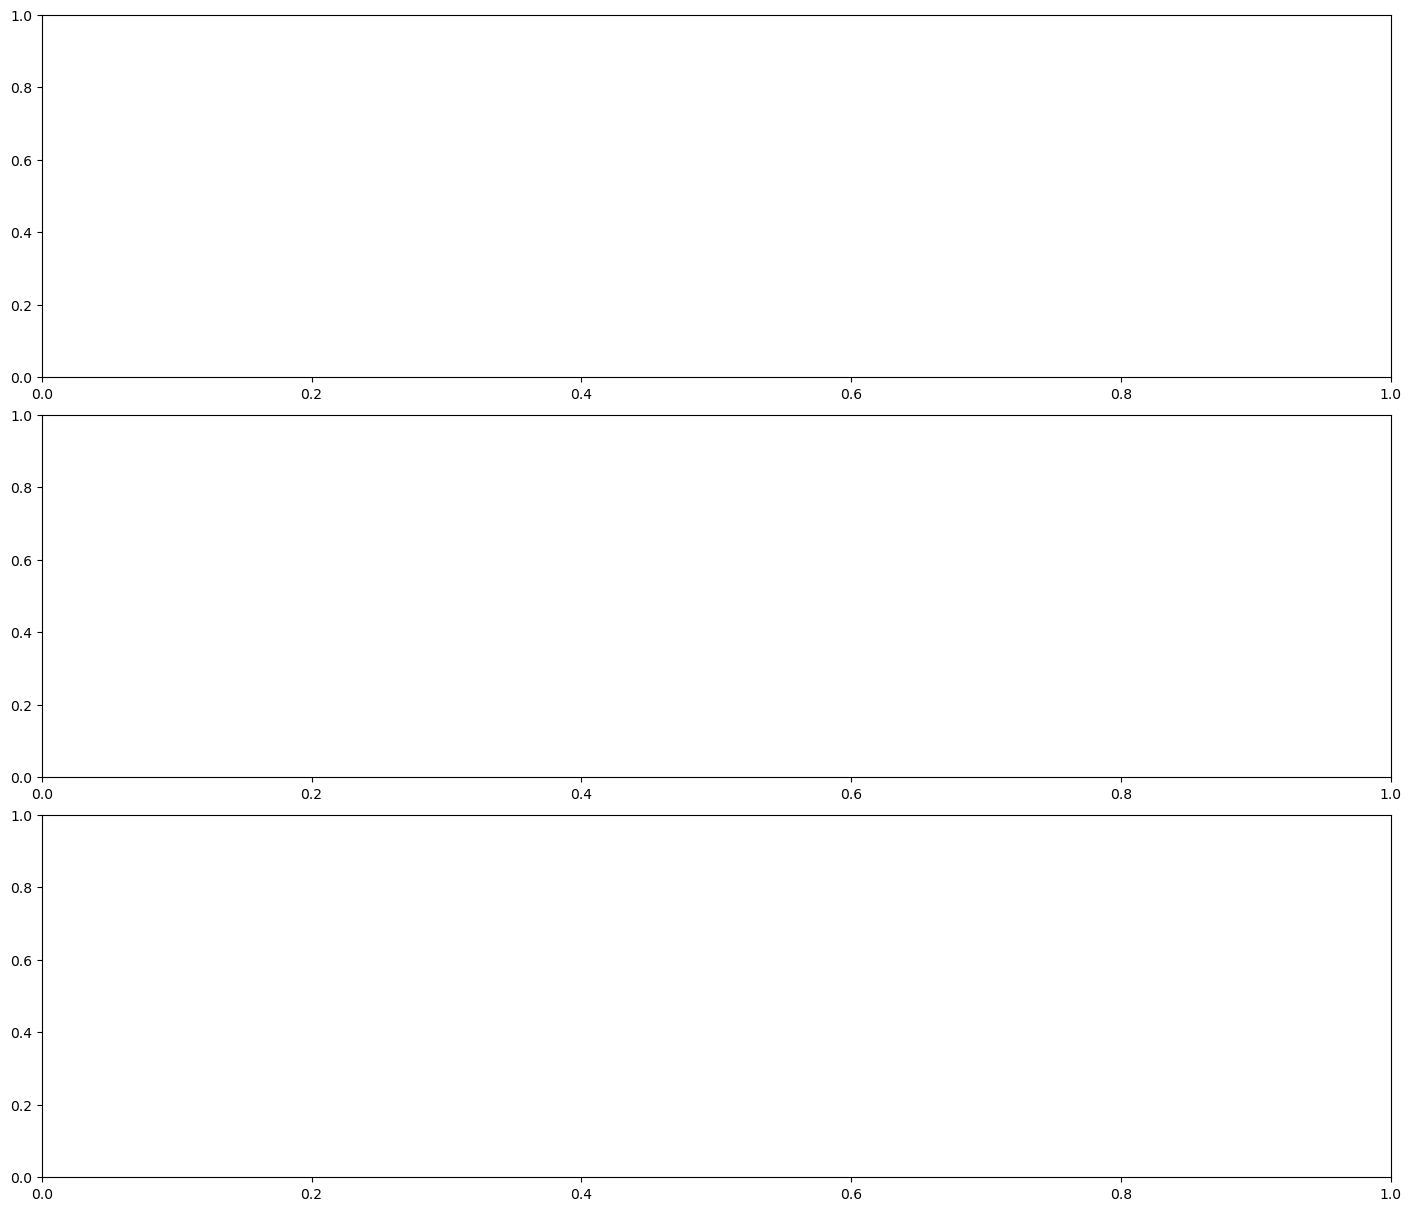

In [36]:
# Duplicate stale plotting cell cleared.
# Use the earlier plotting cell above, which already renders only the three active plots
# with the correct 3 x 1 axis layout.

In [23]:
# Compact table for quick inspection
display_cols = [
    "ij_damping", "split", "alpha", "k", "n_files",
    "uniform_all_covered_mean", "uniform_fraction_covered_mean", "pointwise_fraction_covered_mean",
    "c_uniform_mean", "se_max_mean",
]
agg[display_cols].sort_values(["split", "alpha", "k", "ij_damping"])

,ij_damping,split,alpha,k,n_files,uniform_all_covered_mean,uniform_fraction_covered_mean,pointwise_fraction_covered_mean,c_uniform_mean,se_max_mean
0,0.000100,train,0.05,2,1,1.0,1.000000,1.000000,5.557460,11.231186
2,0.000193,train,0.05,2,1,1.0,1.000000,1.000000,5.865504,2.589369
4,0.000373,train,0.05,2,1,1.0,1.000000,1.000000,6.222092,0.824020
6,0.000431,train,0.05,2,1,1.0,1.000000,1.000000,6.041165,0.673435
8,0.000489,train,0.05,2,1,1.0,1.000000,0.998483,5.897581,0.572123
10,0.000547,train,0.05,2,1,1.0,1.000000,0.993933,5.851941,0.518823
12,0.000720,train,0.05,2,1,1.0,1.000000,0.961577,5.720149,0.448654
14,0.000781,train,0.05,2,1,1.0,1.000000,0.949444,5.669300,0.433931
16,0.000842,train,0.05,2,1,1.0,1.000000,0.938322,5.672683,0.422699
18,0.000902,train,0.05,2,1,1.0,1.000000,0.919616,5.626757,0.413538
